<a href="https://colab.research.google.com/github/pedrodamiaoluz/Redes_Nerais/blob/main/Redes_Neurais_Unidade_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nova seção

In [20]:
import json
import os
import subprocess
from google.colab import userdata

# Function to run a shell command and print its output
def run_command(command):
  print(f"Executing: {command}")
  result = subprocess.run(command, shell=True, capture_output=True, text=True)
  print("Stdout:")
  print(result.stdout)
  print("Stderr:")
  if result.returncode != 0:
    print(f"Command failed with exit code {result.returncode}")
  return result.returncode

print("Attempting to push notebooks to GitHub...")

# Change to the target directory where the git repository is or should be initialized
repo_dir = '/content/Redes_Nerais' # Assuming this is your repository directory
if not os.path.exists(repo_dir):
  print(f"Creating directory: {repo_dir}")
  os.makedirs(repo_dir)

os.chdir(repo_dir)
print(f"Changed current directory to: {os.getcwd()}")

# Configure Git user name and email (IMPORTANT: replace with your actual info)
# These are crucial for making commits. If already set globally or in this session, the commands will be skipped.
# You MUST uncomment and replace the placeholders below if you haven't configured them.
if run_command('git config user.email') != 0: # Check if email is already set
  run_command('git config user.email "your_email@example.com"') # <--- REPLACE WITH YOUR EMAIL
if run_command('git config user.name') != 0: # Check if name is already set
  run_command('git config user.name "Your Name"') # <--- REPLACE WITH YOUR NAME

# Check if it's a git repository, if not, initialize it
if run_command('git rev-parse --is-inside-work-tree') != 0:
  print("Initializing new Git repository...")
  if run_command('git init') != 0:
    print("Failed to initialize Git repository. Please check permissions or existing .git folder.")
    exit()

# --- Configuration for copying notebooks ---
# IMPORTANT: Specify the Google Drive folder where your notebooks are located.
# The script will copy ALL .ipynb files from this directory to your Git repository.
source_notebook_dir = "/content/drive/MyDrive/Redes Neurais Unidade I"

# Find all .ipynb files in the source directory
# We use 'find' command to recursively search, but you can adjust if needed.
find_notebooks_command = f'find "{source_notebook_dir}" -name "*.ipynb"'
result = subprocess.run(find_notebooks_command, shell=True, capture_output=True, text=True)
notebook_files_to_copy = result.stdout.strip().splitlines()

# Filter out empty strings if any
notebook_files_to_copy = [f for f in notebook_files_to_copy if f]

if not notebook_files_to_copy:
    print(f"No .ipynb notebooks found in {source_notebook_dir}. Please check the path and ensure notebooks exist.")
else:
    # Copy each found notebook file to the current repository directory
    for notebook_path in notebook_files_to_copy:
        if os.path.exists(notebook_path):
            print(f"Copying {os.path.basename(notebook_path)} to repository...")
            copy_command = f'cp "{notebook_path}" .'
            run_command(copy_command)
        else:
            # This case should ideally not happen if 'find' worked correctly and path exists
            print(f"Warning: Notebook not found at {notebook_path}. Skipping copy.")

# Stage all changes (add the current directory and its contents)
# This will now include the new/updated notebooks.
if run_command('git add .') == 0:
  # Commit changes
  # Check if there are any changes to commit
  # Using 'git status --porcelain' to detect actual changes to commit
  commit_check_result = subprocess.run('git status --porcelain', shell=True, capture_output=True, text=True)
  if commit_check_result.stdout.strip(): # If stdout is not empty, there are changes
    # Commit message can be customized or made dynamic based on current date/time.
    if run_command('git commit -m "chore: Automatic upload of new/updated notebooks from Colab"') == 0:
      # Push to origin main
      # Make sure 'origin' remote is set and you are authenticated
      run_command('git push origin main')
    else:
      print("Git commit failed.")
  else:
    print("No changes detected to commit. Working tree clean.")
else:
  print("Git add failed. No changes were staged.")

print("Push attempt finished.")

Attempting to push notebooks to GitHub...
Changed current directory to: /content/Redes_Nerais
Executing: git config user.email
Stdout:
pedrodamiao26061998@gmail.com

Stderr:
Executing: git config user.name
Stdout:
pedrodamiaoluz

Stderr:
Executing: git rev-parse --is-inside-work-tree
Stdout:
true

Stderr:
Copying adaline.ipynb to repository...
Executing: cp "/content/drive/MyDrive/Redes Neurais Unidade I/adaline.ipynb" .
Stdout:

Stderr:
Copying perceptron_original.ipynb to repository...
Executing: cp "/content/drive/MyDrive/Redes Neurais Unidade I/perceptron_original.ipynb" .
Stdout:

Stderr:
Copying modelo_neuronio.ipynb to repository...
Executing: cp "/content/drive/MyDrive/Redes Neurais Unidade I/modelo_neuronio.ipynb" .
Stdout:

Stderr:
Copying Exercicio_2_Algoritmos_de_Otimizacao.ipynb to repository...
Executing: cp "/content/drive/MyDrive/Redes Neurais Unidade I/Exercicio_2_Algoritmos_de_Otimizacao.ipynb" .
Stdout:

Stderr:
Executing: git add .
Stdout:

Stderr:
No changes detect

In [19]:
!find /content -name "*.ipynb"

/content/drive/MyDrive/Redes Neurais Unidade I/adaline.ipynb
/content/drive/MyDrive/Redes Neurais Unidade I/perceptron_original.ipynb
/content/drive/MyDrive/Redes Neurais Unidade I/modelo_neuronio.ipynb
/content/drive/MyDrive/Redes Neurais Unidade I/Exercicio_2_Algoritmos_de_Otimizacao.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled1.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled2.ipynb
/content/drive/MyDrive/Colab Notebooks/Aula de Python.ipynb
/content/Redes_Nerais/modelo_neuronio.ipynb
/content/Redes_Nerais/Exercicio_2_Algoritmos_de_Otimizacao.ipynb
/content/Redes_Nerais/perceptron_original.ipynb
/content/Redes_Nerais/adaline.ipynb



[Link do Github](https://github.com/roscibely/neural_networks/blob/main/unidadeI/aula01/notebooks/modelo_neuronio.ipynb)

# **Modelo do Neurônio**

**Objetivos**

- Entender o modelo matemático do neurônio artificial.
- Implementar um neurônio simples em Python.

---

#### Modelo do Neurônio Artificial

O neurônio artificial recebe entradas $x_1, x_2, ..., x_n$, cada uma com um peso $w_1, w_2, ..., w_n$.

Ele calcula uma **combinação linear** e depois aplica uma **função de ativação**.

$$
y = f\left(\sum_{i=1}^{n} w_i x_i + b \right)
$$

onde:

- $x_i$ → entradas  
- $w_i$ → pesos sinápticos  
- $b$ → bias (limiar)  
- $f(\cdot)$ → função de ativação  
- $y$ → saída do neurônio  

---

## Função de Ativação

Para uma aula inicial, normalmente usamos a **função degrau**:

$$
f(z) =
\begin{cases}
1 & \text{se } z \ge 0 \\
0 & \text{se } z < 0
\end{cases}
$$





In [ ]:
import numpy as np

def ativacao(soma):
  if soma >= 0:
    return 1
  else:
    return 0

def neuronio(x, w, theta):
  """
  Args
    x: vetror entradas
    w: vetor pesos
    theta: bias
  Return:
    y: saída do neurônio
  """
  soma = np.dot(x, w + theta)
  y = ativacao(soma)
  return y


In [ ]:
x = np.array([1, 0])
w = np.array([0.5, 0.2])
theta = 0.5

saida = neuronio(x, w, theta)
print("A saida é: ", saida)

A saida é:  1


# **Rede Perceptron (Original)**

**Objetivos**

- Apresentar a regra de aprendizagem do perceptron.
- Implementar o perceptron e treinar em conjuntos linearly separable.
- Visualizar fronteiras de decisão e métricas de desempenho.

---

## Treinamento da Rede Perceptron

Para implementar a **rede Perceptron com treinamento**, exatamente como foi proposta por **Frank Rosenblatt**, seguimos as etapas abaixo.

---

### 1. Propagação Direta

A saída do neurônio é calculada por:

$$
y = f\left(\sum_{i=1}^{n} x_i w_i + b \right)
$$

onde a função de ativação $f(\cdot)$ normalmente é a **função degrau**.

---

### 2. Cálculo do Erro

O erro é a diferença entre a saída desejada e a saída produzida pelo neurônio:

$$
e = d - y
$$

---

### 3. Atualização dos Pesos (Regra Delta)

Os pesos são atualizados utilizando a **regra de aprendizado do Perceptron**:

$$
w_i = w_i + \eta \, e \, x_i
$$

e o bias é atualizado por:

$$
b = b + \eta \, e
$$

---

### Parâmetros

- $d$ → saída desejada  
- $y$ → saída do neurônio  
- $e$ → erro  
- $\eta$ → taxa de aprendizado


# **Exemplo Prático: Rede Perceptron (Original)**

In [ ]:
import numpy as np

class Perceptron:
  def __init__(self, input_size):
    self.weights = np.zeros(input_size) # W
    self.bias = 0

  def activation(self, sum):
    if sum >= 0:
      return 1
    else:
      return 0


  def output(self, inputs):
    sum = np.dot(inputs, self.weights) + self.bias
    output_perceptron = self.activation(sum)
    return output_perceptron

  def train(self, input, output, epoch=10, learnin_rate=1):
    for count in range(epoch):
      for input_in,  output_in in zip(input, output):
        output_perceptron = self.output(input_in)
        self.weights += learnin_rate*(output_in - output_perceptron) * input_in # atualição pesos
        self.bias += learnin_rate*(output_in - output_perceptron) # atualização bias
      print(count, "epoch === Erro:", output_in - output_perceptron)


In [ ]:
input = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
output = np.array([0, 1, 1, 1])

perceptron = Perceptron(input_size=2)
perceptron.train(input, output, epoch=15, learnin_rate=0.1)

0 epoch === Erro: 0
1 epoch === Erro: 0
2 epoch === Erro: 0
3 epoch === Erro: 0
4 epoch === Erro: 0
5 epoch === Erro: 0
6 epoch === Erro: 0
7 epoch === Erro: 0
8 epoch === Erro: 0
9 epoch === Erro: 0
10 epoch === Erro: 0
11 epoch === Erro: 0
12 epoch === Erro: 0
13 epoch === Erro: 0
14 epoch === Erro: 0


In [ ]:
import matplotlib.pyplot as plt

def plot_hyperplane(weights, bias):
  input = np.linspace(-0.1, 1.1, 100)
  h = (-bias - weights[0]*input)/weights[1]
  plt.plot(input, h, label="Hiperplano encontrado")
  plt.legend()

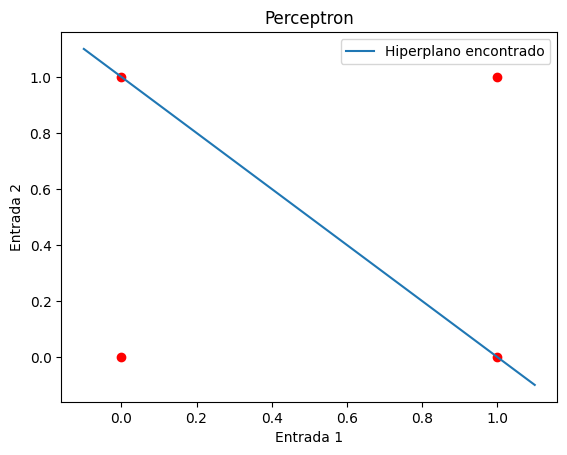

In [ ]:
plot_hyperplane(perceptron.weights, perceptron.bias)
plt.scatter(input[:, 0], input[:, 1], color="red")
plt.xlabel("Entrada 1")
plt.ylabel("Entrada 2")
plt.title("Perceptron")
plt.legend()
plt.show()

In [ ]:
input = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
output = np.array([0, 0, 0, 1])

perceptron = Perceptron(input_size=2)
perceptron.train(input, output, epoch=50, learnin_rate=0.1)

0 epoch === Erro: 1
1 epoch === Erro: 1
2 epoch === Erro: 1
3 epoch === Erro: 0
4 epoch === Erro: 0
5 epoch === Erro: 0
6 epoch === Erro: 0
7 epoch === Erro: 0
8 epoch === Erro: 0
9 epoch === Erro: 0
10 epoch === Erro: 0
11 epoch === Erro: 0
12 epoch === Erro: 0
13 epoch === Erro: 0
14 epoch === Erro: 0
15 epoch === Erro: 0
16 epoch === Erro: 0
17 epoch === Erro: 0
18 epoch === Erro: 0
19 epoch === Erro: 0
20 epoch === Erro: 0
21 epoch === Erro: 0
22 epoch === Erro: 0
23 epoch === Erro: 0
24 epoch === Erro: 0
25 epoch === Erro: 0
26 epoch === Erro: 0
27 epoch === Erro: 0
28 epoch === Erro: 0
29 epoch === Erro: 0
30 epoch === Erro: 0
31 epoch === Erro: 0
32 epoch === Erro: 0
33 epoch === Erro: 0
34 epoch === Erro: 0
35 epoch === Erro: 0
36 epoch === Erro: 0
37 epoch === Erro: 0
38 epoch === Erro: 0
39 epoch === Erro: 0
40 epoch === Erro: 0
41 epoch === Erro: 0
42 epoch === Erro: 0
43 epoch === Erro: 0
44 epoch === Erro: 0
45 epoch === Erro: 0
46 epoch === Erro: 0
47 epoch === Erro: 0
48

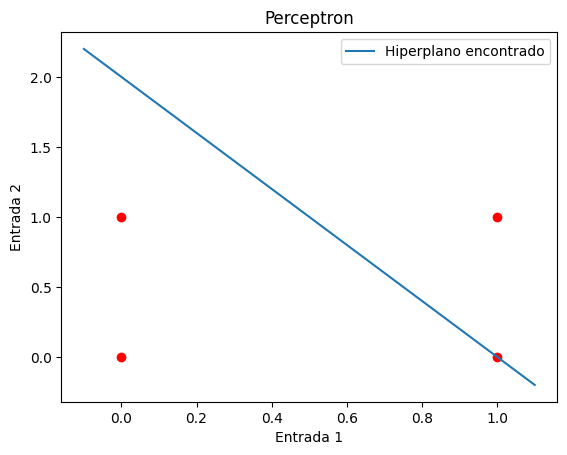

In [ ]:
plot_hyperplane(perceptron.weights, perceptron.bias)
plt.scatter(input[:, 0], input[:, 1], color="red")
plt.xlabel("Entrada 1")
plt.ylabel("Entrada 2")
plt.title("Perceptron")
plt.legend()
plt.show()

In [ ]:
input = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
output = np.array([0, 1, 1, 0])

perceptron = Perceptron(input_size=2)
perceptron.train(input, output, epoch=50, learnin_rate=0.1)

0 epoch === Erro: -1
1 epoch === Erro: -1
2 epoch === Erro: -1
3 epoch === Erro: -1
4 epoch === Erro: -1
5 epoch === Erro: -1
6 epoch === Erro: -1
7 epoch === Erro: -1
8 epoch === Erro: -1
9 epoch === Erro: -1
10 epoch === Erro: -1
11 epoch === Erro: -1
12 epoch === Erro: -1
13 epoch === Erro: -1
14 epoch === Erro: -1
15 epoch === Erro: -1
16 epoch === Erro: -1
17 epoch === Erro: -1
18 epoch === Erro: -1
19 epoch === Erro: -1
20 epoch === Erro: -1
21 epoch === Erro: -1
22 epoch === Erro: -1
23 epoch === Erro: -1
24 epoch === Erro: -1
25 epoch === Erro: -1
26 epoch === Erro: -1
27 epoch === Erro: -1
28 epoch === Erro: -1
29 epoch === Erro: -1
30 epoch === Erro: -1
31 epoch === Erro: -1
32 epoch === Erro: -1
33 epoch === Erro: -1
34 epoch === Erro: -1
35 epoch === Erro: -1
36 epoch === Erro: -1
37 epoch === Erro: -1
38 epoch === Erro: -1
39 epoch === Erro: -1
40 epoch === Erro: -1
41 epoch === Erro: -1
42 epoch === Erro: -1
43 epoch === Erro: -1
44 epoch === Erro: -1
45 epoch === Erro: -

/tmp/ipykernel_2202/3416028988.py:5: RuntimeWarning: divide by zero encountered in divide
  h = (-bias - weights[0]*input)/weights[1]


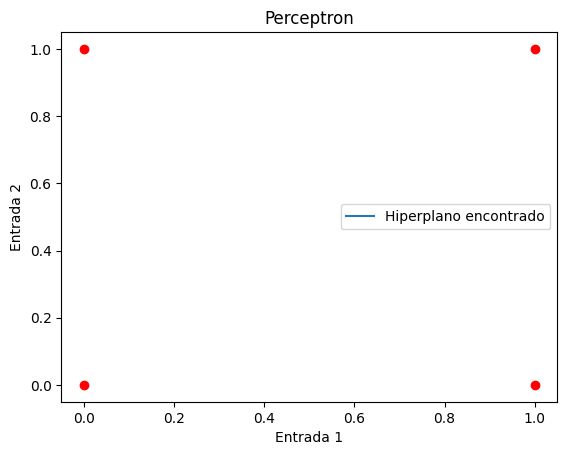

In [ ]:
plot_hyperplane(perceptron.weights, perceptron.bias)
plt.scatter(input[:, 0], input[:, 1], color="red")
plt.xlabel("Entrada 1")
plt.ylabel("Entrada 2")
plt.title("Perceptron")
plt.legend()
plt.show()

# **Modelo do Neurônio Adaline**

O modelo interno do **Adaline (Adaptive Linear Neuron)** é linear:

$$
y = w^T x + b
$$

ou, de forma expandida,

$$
y = \sum_{i=1}^{n} w_i x_i + b
$$

---

### Diferença em relação ao Perceptron

A principal diferença é que:

**o erro é calculado antes da função de ativação.**

No **Perceptron**:

$$
erro = d - f(w^T x)
$$

No **Adaline**:

$$
erro = d - (w^T x)
$$

---

## Função de Custo

O Adaline minimiza o **Erro Quadrático Médio (MSE)**:

$$
J(w) = \frac{1}{2} \sum (d - y)^2
$$

onde

- $d$ → saída desejada  
- $y$ → saída linear do neurônio  

---

## Regra de Treinamento (Regra LMS)

O algoritmo usado é chamado de **LMS — Least Mean Squares**.

Atualização dos pesos:

$$
w_i \leftarrow w_i + \eta (d - y)x_i
$$

Atualização do bias:

$$
b \leftarrow b + \eta (d - y)
$$

onde

- $\eta$ → taxa de aprendizado.

Essa regra é derivada diretamente do **gradiente descendente aplicado ao MSE**.

---

## Etapas do Treinamento

### 1. Inicializar pesos

Inicializar pesos e bias com valores pequenos ou aleatórios.

---

### 2. Para cada exemplo $x$

**Saída linear**

$$
y = w^T x + b
$$

**Erro**

$$
e = d - y
$$

**Atualização dos pesos**

$$
w_i = w_i + \eta e x_i
$$





**Repetir o processo**

* Repetir por várias épocas até minimizar o erro.










# Exemplo Prático: Modelo do Neurônio Adaline

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class Adaline:

  def __init__(self, n_inputs, eta=0.1):
    self.w = np.zeros(n_inputs)
    self.b = 0
    self.eta = eta

  def predict(self, x):
    return np.dot(x, self.w) + self.b

  def train(self, X, d, epochs):
    for epoch in range(epochs):
      for i in range(len(X)):
        y = self.predict(X[i])
        error = d[i] - y
        self.w += self.eta * error * X[i]
        self.b += self.eta * error

      print("Epoca:", epoch+1, "Pesos:", self.w)




Epoca: 1 Pesos: [0.1 0.1]
Epoca: 2 Pesos: [0.16112 0.15922]
Epoca: 3 Pesos: [0.20258054 0.19808926]
Epoca: 4 Pesos: [0.23371999 0.22650395]
Epoca: 5 Pesos: [0.25910386 0.24927607]
Epoca: 6 Pesos: [0.28099036 0.26876266]
Epoca: 7 Pesos: [0.3005204  0.28613437]
Epoca: 8 Pesos: [0.31829198 0.30198762]
Epoca: 9 Pesos: [0.33463769 0.31664003]
Epoca: 10 Pesos: [0.34975884 0.3302731 ]
Epoca: 11 Pesos: [0.3637904  0.34300101]
Epoca: 12 Pesos: [0.3768326  0.35490402]
Epoca: 13 Pesos: [0.38896637 0.36604455]
Epoca: 14 Pesos: [0.40026095 0.37647506]
Epoca: 15 Pesos: [0.41077779 0.38624192]
Epoca: 16 Pesos: [0.42057256 0.39538734]
Epoca: 17 Pesos: [0.42969627 0.40395035]
Epoca: 18 Pesos: [0.43819596 0.41196733]
Epoca: 19 Pesos: [0.44611517 0.41947238]
Epoca: 20 Pesos: [0.45349427 0.42649746]
Epoca: 21 Pesos: [0.46037069 0.43307262]
Epoca: 22 Pesos: [0.46677923 0.43922606]
Epoca: 23 Pesos: [0.47275219 0.44498428]
Epoca: 24 Pesos: [0.47831962 0.45037219]
Epoca: 25 Pesos: [0.48350942 0.45541315]
Epoc

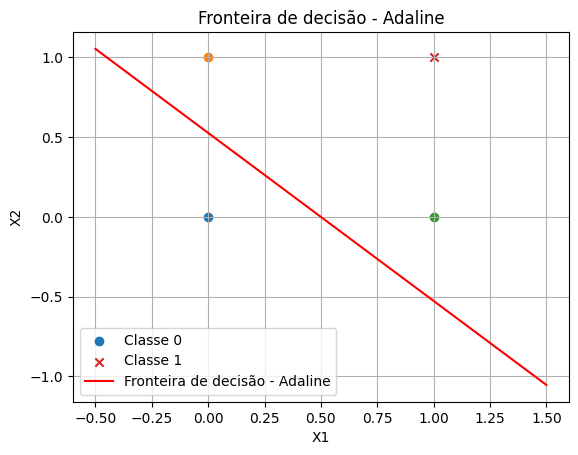

In [ ]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
d = np.array([0, 0, 0, 1])

adaline = Adaline(2)
adaline.train(X, d, 100)

w1 = adaline.w[0]
w2 = adaline.w[1]
b = adaline.b

x1 = np.linspace(-0.5, 1.5,100)
x2 = -(w1 * x1 + b) / w2

for i in range(len(X)):
  if d[i] == 0:
    plt.scatter(X[i][0], X[i][1], marker="o", label="Classe 0" if i==0 else "")
  else:
    plt.scatter(X[i][0], X[i][1], marker="x", label="Classe 1" if i==3 else "")

plt.plot(x1, x2, color="red", label="Fronteira de decisão - Adaline")
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Fronteira de decisão - Adaline")

plt.legend()
plt.grid(True)
plt.show()

# Aula 03

[keras](https://keras.io/api/)



# **1. Exercício: Modificar o algoritmo para o cálculo do gradiente:** [keras](https://keras.io/api/optimizers/)

* SGD
* RMSprop
* Adam
* AdamW
* Adadelta
* Adagrad

# **2. Exercício para 🏠**

## Pesquisar sobre os diferentes algoritmos de otimização que são usados durante o treinamento das redes profundas. Você deve apresentar as vantagens e desvantagens dos algoritmos e o porquê eles foram criados. Mostrar também a formulação matemática dos métodos.

Obs: Deve ser feito a mão.

## Introdução

Os algoritmos de otimização são utilizados durante o treinamento das redes neurais para atualizar os pesos da rede e minimizar a função de perda. Eles determinam como os parâmetros do modelo devem ser modificados a partir dos gradientes calculados pelo backpropagation.

## Objetivo

Pesquisar os diferentes algoritmos de otimização usados durante o treinamento de redes profundas, apresentando **por que foram criados, vantagens, desvantagens e formulação matemática**.

### Algoritmos estudados

SGD, RMSprop, Adam, AdamW, Adadelta, Adagrad, Adamax, Adafactor, Nadam, FTRL, Lion, LAMB, Loss Scale Optimizer, MultiOptimizer, OptimizerMap e Muon.

> **Observação:** Loss Scale Optimizer, MultiOptimizer e OptimizerMap são mecanismos auxiliares relacionados à otimização, e não novos métodos de descida do gradiente no mesmo sentido de SGD ou Adam.


# 1. SGD — Stochastic Gradient Descent

Foi criado para realizar a descida do gradiente usando amostras ou pequenos lotes de dados, reduzindo o custo de calcular o gradiente sobre todo o conjunto.

## Formulação matemática


$$
w_{t+1}=w_{t}-\eta \nabla Q_{i}(w_{t})\
$$

Onde:

* \(w_{t}\): Peso atual da rede neural antes da atualização.
* \(w_{t+1}\): Novo peso atualizado.
* η (eta): Taxa de aprendizado (learning rate), um número pequeno que define o tamanho do passo dado na direção do gradiente.
* \(\nabla Q_i(w_t)\): Gradiente da função de perda (ou custo) calculada apenas para o i-ésimo exemplo de dado individual \((x^{(i)}, y^{(i)})\):

$$
\nabla Q_{i}(w_{t})=\frac{\partial L(f(x^{(i)};w_{t}),y^{(i)})}{\partial w_{t}}\
$$

## Vantagens
- Simples de implementar.
- Baixo consumo de memória.
- Pode apresentar boa generalização.

## Desvantagens
- Pode oscilar durante o treinamento.
- Pode convergir lentamente.
- É sensível à taxa de aprendizado.



# 2. RMSprop

## Por que foi criado?

Foi criado para reduzir oscilações e adaptar a taxa de aprendizado de cada parâmetro usando uma média móvel dos quadrados dos gradientes.

## Formulação matemática

$$
v_t=\rho v_{t-1}+(1-\rho)g_t^2
$$

$$
\theta_{t+1}=\theta_t-\frac{\eta}{\sqrt{v_t}+\varepsilon}g_t
$$

## Vantagens
- Adapta a taxa de aprendizado por parâmetro.
- Reduz oscilações.
- Funciona bem em redes profundas.

## Desvantagens
- Possui mais hiperparâmetros que SGD.
- Pode exigir ajuste da taxa de aprendizado.
- Não é necessariamente superior aos métodos modernos.


# 3. Adam — Adaptive Moment Estimation

## Por que foi criado?

Foi criado para combinar momentum, representado pelo primeiro momento, com uma taxa de aprendizado adaptativa baseada no segundo momento.

## Formulação matemática

Primeiro momento:

$$
m_t=\beta_1m_{t-1}+(1-\beta_1)g_t
$$

Segundo momento:

$$
v_t=\beta_2v_{t-1}+(1-\beta_2)g_t^2
$$

Correção do viés:

$$
\hat m_t=\frac{m_t}{1-\beta_1^t}
\qquad
\hat v_t=\frac{v_t}{1-\beta_2^t}
$$

Atualização:

$$
\theta_{t+1}
=
\theta_t-\eta\frac{\hat m_t}{\sqrt{\hat v_t}+\varepsilon}
$$

## Vantagens
- Converge rapidamente em muitos problemas.
- Adapta a taxa de aprendizado por parâmetro.
- Muito utilizado em redes profundas.

## Desvantagens
- Usa mais memória que SGD.
- Pode apresentar pior generalização em alguns problemas.
- Possui vários hiperparâmetros.



# 4. AdamW

## Por que foi criado?

Foi criado para melhorar a aplicação da regularização por weight decay, separando o decaimento dos pesos da atualização adaptativa do Adam.

## Formulação matemática

$$
\theta_{t+1}
=
\theta_t
-
\eta\frac{\hat m_t}{\sqrt{\hat v_t}+\varepsilon}
-
\eta\lambda\theta_t
$$

O termo $-\eta\lambda\theta_t$ representa o **weight decay**.

## Vantagens
- Mantém as vantagens do Adam.
- Ajuda a controlar overfitting.
- Weight decay aplicado de forma desacoplada.

## Desvantagens
- Usa mais memória que SGD.
- O weight decay precisa ser ajustado.
- Possui mais hiperparâmetros.



# 5. Adadelta

## Por que foi criado?

Foi criado para reduzir o problema do Adagrad, no qual a taxa de aprendizado tende a diminuir continuamente.

## Formulação matemática

$$
E[g^2]_t=\rho E[g^2]_{t-1}+(1-\rho)g_t^2
$$

$$
\Delta\theta_t=
-\frac{\eta}{\sqrt{E[g^2]_t+\varepsilon}}g_t
$$

$$
\theta_{t+1}=\theta_t+\Delta\theta_t
$$

## Vantagens
- Reduz o problema da diminuição contínua da taxa.
- Adapta a taxa durante o treinamento.
- Pode funcionar bem em diferentes problemas.

## Desvantagens
- Pode ter desempenho inferior ao Adam.
- Possui parâmetros para configurar.
- É menos utilizado atualmente.



# 6. Adagrad

## Por que foi criado?

Foi criado para permitir que cada parâmetro tenha uma taxa de aprendizado adaptativa, sendo especialmente útil em problemas com dados esparsos.

## Formulação matemática

$$
G_t=G_{t-1}+g_t^2
$$

$$
\theta_{t+1}
=
\theta_t-
\frac{\eta}{\sqrt{G_t}+\varepsilon}g_t
$$

## Vantagens
- Adapta a taxa de aprendizado por parâmetro.
- Funciona bem com dados esparsos.
- É relativamente simples.

## Desvantagens
- A taxa de aprendizado diminui continuamente.
- Pode chegar a atualizações muito pequenas.
- Pode ter desempenho inferior a métodos mais modernos.



# 7. Adamax

## Por que foi criado?

É uma variação do Adam baseada na norma infinita, criada para obter atualizações mais estáveis em algumas situações com grande variação dos gradientes.

## Formulação matemática

$$
m_t=\beta_1m_{t-1}+(1-\beta_1)g_t
$$

$$
u_t=\max(\beta_2u_{t-1},|g_t|)
$$

$$
\hat m_t=\frac{m_t}{1-\beta_1^t}
$$

$$
\theta_{t+1}=\theta_t-\frac{\eta}{u_t}\hat m_t
$$

## Vantagens
- Taxa de aprendizado adaptativa.
- Pode ser estável com gradientes variados.
- É uma alternativa ao Adam.

## Desvantagens
- Pode não superar Adam.
- Possui hiperparâmetros.
- É menos utilizado.



# 8. Adafactor

## Por que foi criado?

Foi criado para reduzir o consumo de memória no treinamento de modelos muito grandes, aproximando o segundo momento por fatores de linha e coluna.

## Formulação matemática

$$
V_t=\beta_2V_{t-1}+(1-\beta_2)G_t^2
$$

A aproximação utiliza estatísticas de linhas e colunas:

$$
R_t=\beta_2R_{t-1}+(1-\beta_2)\operatorname{mean}_{col}(G_t^2)
$$

$$
C_t=\beta_2C_{t-1}+(1-\beta_2)\operatorname{mean}_{row}(G_t^2)
$$

Atualização simplificada:

$$
\theta_{t+1}
=
\theta_t-\eta_t\frac{G_t}{\sqrt{V_t}+\varepsilon}
$$

## Vantagens
- Reduz consumo de memória.
- Adequado para modelos muito grandes.
- Pode viabilizar treinamento em menor memória.

## Desvantagens
- Mais complexo que SGD e Adam.
- Pode exigir configuração cuidadosa.
- Nem sempre traz vantagem em modelos pequenos.



# 9. Nadam

## Por que foi criado?

Combina Adam com Nesterov Momentum, buscando aproveitar a adaptação da taxa de aprendizado do Adam com a antecipação do momentum de Nesterov.

## Formulação matemática

$$
m_t=\beta_1m_{t-1}+(1-\beta_1)g_t
$$

$$
v_t=\beta_2v_{t-1}+(1-\beta_2)g_t^2
$$

$$
\hat m_t=\frac{m_t}{1-\beta_1^t}
\qquad
\hat v_t=\frac{v_t}{1-\beta_2^t}
$$

A atualização utiliza uma forma de momentum de Nesterov:

$$
\theta_{t+1}
=
\theta_t-
\eta\frac{\text{termo de momentum}}{\sqrt{\hat v_t}+\varepsilon}
$$

## Vantagens
- Pode apresentar convergência rápida.
- Combina Adam com Nesterov.
- Adequado para redes profundas.

## Desvantagens
- Mais complexo que SGD.
- Possui vários hiperparâmetros.
- Nem sempre supera Adam.



# 10. FTRL — Follow-The-Regularized-Leader

## Por que foi criado?

Foi desenvolvido para aprendizado em grande escala, especialmente com dados esparsos, como sistemas de recomendação e publicidade online.

## Formulação matemática

$$
\theta_{t+1}
=
\arg\min_\theta
\left[
\sum_{s=1}^{t}g_s^T\theta
+
\frac{1}{2\eta_t}\|\theta-\theta_0\|^2
+
R(\theta)
\right]
$$

onde $R(\theta)$ representa a regularização.

## Vantagens
- Adequado para dados esparsos.
- Permite regularização L1 e L2.
- Útil em grandes conjuntos de dados.

## Desvantagens
- Mais complexo que SGD.
- Menos utilizado em redes profundas tradicionais.
- Possui vários hiperparâmetros.



# 11. Lion — Evolved Sign Momentum

## Por que foi criado?

Foi criado buscando boa eficiência com menor uso de memória que otimizadores adaptativos que armazenam o segundo momento, como Adam.

## Formulação matemática

$$
c_t=\beta_1m_t+(1-\beta_1)g_t
$$

Atualização pelo sinal:

$$
\theta_{t+1}
=
\theta_t-\eta\,\operatorname{sign}(c_t)
$$

Momentum:

$$
m_{t+1}
=
\beta_2m_t+(1-\beta_2)g_t
$$

## Vantagens
- Usa menos memória que Adam.
- Regra de atualização simples.
- Pode funcionar bem em modelos grandes.

## Desvantagens
- Pode exigir ajuste cuidadoso da taxa de aprendizado.
- O sinal elimina informação de magnitude do gradiente.
- É mais recente que Adam.



# 12. LAMB — Layer-wise Adaptive Moments optimizer for Batch training

## Por que foi criado?

Foi criado para facilitar o treinamento de modelos grandes usando batches muito grandes, adaptando a atualização de acordo com as normas dos pesos e do passo.

## Formulação matemática

$$
m_t=\beta_1m_{t-1}+(1-\beta_1)g_t
$$

$$
v_t=\beta_2v_{t-1}+(1-\beta_2)g_t^2
$$

$$
\hat m_t=\frac{m_t}{1-\beta_1^t}
\qquad
\hat v_t=\frac{v_t}{1-\beta_2^t}
$$

$$
r_t=\frac{\hat m_t}{\sqrt{\hat v_t}+\varepsilon}
$$

Trust ratio:

$$
\phi_t=\frac{\|\theta_t\|}{\|r_t\|}
$$

Atualização:

$$
\theta_{t+1}=\theta_t-\eta\phi_t r_t
$$

## Vantagens
- Adequado para batches grandes.
- Pode acelerar treinamento de modelos grandes.
- Adapta o passo por camada.

## Desvantagens
- Mais complexo que Adam.
- Pode não trazer benefícios em modelos pequenos.
- Possui mais cálculos e hiperparâmetros.



# 13. Loss Scale Optimizer

## Por que foi criado?

É um mecanismo auxiliar usado principalmente em treinamento com precisão mista, como float16. Foi criado para reduzir problemas de underflow quando os gradientes são muito pequenos.

## Formulação matemática

Escala da perda:

$$
L'=S\cdot L
$$

Gradiente escalado:

$$
g'=\nabla L'=S\nabla L
$$

Recuperação do gradiente:

$$
g=\frac{g'}{S}
$$

Atualização pelo otimizador original:

$$
\theta_{t+1}=\theta_t-\eta g
$$

## Vantagens
- Ajuda a evitar underflow.
- Útil em precisão mista.
- Pode melhorar a eficiência em hardware moderno.

## Desvantagens
- Não é um algoritmo de otimização independente.
- É principalmente útil em baixa precisão.
- O fator de escala precisa ser controlado.



# 14. MultiOptimizer

## Por que foi criado?

Permite utilizar diferentes otimizadores em diferentes partes do mesmo modelo, dando maior controle sobre a atualização dos parâmetros.

## Formulação matemática

Considere:

$$
\theta=\{\theta_1,\theta_2\}
$$

Podemos usar Adam em $\theta_1$:

$$
\theta_1^{t+1}
=
\operatorname{Adam}
\left(\theta_1^t,\nabla J(\theta_1)\right)
$$

e SGD em $\theta_2$:

$$
\theta_2^{t+1}
=
\theta_2^t-\eta_2\nabla J(\theta_2)
$$

## Vantagens
- Combina diferentes estratégias no mesmo modelo.
- Oferece maior controle.
- Útil em arquiteturas com partes diferentes.

## Desvantagens
- Aumenta a complexidade.
- Exige configuração de vários otimizadores.
- Pode dificultar o ajuste dos hiperparâmetros.



# 15. OptimizerMap

## Por que foi criado?

É um mecanismo para associar determinados parâmetros ou partes do modelo a diferentes otimizadores.

## Formulação matemática

Para:

$$
\theta=\{\theta_1,\theta_2,\ldots,\theta_n\}
$$

define-se:

$$
f(\theta_i)=O_i
$$

onde $O_i$ é o otimizador associado ao parâmetro $\theta_i$.

Assim:

$$
\theta_i^{t+1}
=
O_i\left(\theta_i^t,\nabla J(\theta_i)\right)
$$

## Vantagens
- Permite diferentes otimizadores em diferentes partes.
- Organiza estratégias complexas.
- Pode trabalhar junto com múltiplos otimizadores.

## Desvantagens
- Não é um algoritmo independente.
- Aumenta a complexidade do código.
- Pode dificultar a configuração.



# 16. Muon

## Por que foi criado?

É um otimizador moderno voltado principalmente para matrizes de parâmetros. Utiliza momentum e uma normalização aproximada baseada no método de Newton-Schulz.

## Formulação matemática

Momentum:

$$
M_t=\mu M_{t-1}+g_t
$$

Normalização aproximada de Newton-Schulz:

$$
X_{k+1}
=
aX_k+bX_kX_k^TX_k
+cX_kX_k^TX_kX_k^TX_k
$$

Obtém-se uma aproximação:

$$
U_t\approx\operatorname{NS}(M_t)
$$

Atualização simplificada:

$$
\theta_{t+1}=\theta_t-\eta U_t
$$

## Vantagens
- Voltado para otimização eficiente de grandes modelos.
- Explora operações matriciais.
- Pode apresentar boa eficiência em modelos modernos.

## Desvantagens
- Mais complexo que Adam e SGD.
- É relativamente recente.
- Não é adequado indiscriminadamente para todos os parâmetros.



# Tabela comparativa

| Algoritmo | Principal objetivo |
|---|---|
| **SGD** | Descida do gradiente simples |
| **RMSprop** | Adaptar a taxa de aprendizado |
| **Adam** | Combinar momentum e adaptação da taxa |
| **AdamW** | Adam com weight decay desacoplado |
| **Adadelta** | Corrigir a redução excessiva da taxa do Adagrad |
| **Adagrad** | Adaptar a taxa para cada parâmetro |
| **Adamax** | Utilizar a norma infinita no Adam |
| **Adafactor** | Reduzir o consumo de memória |
| **Nadam** | Combinar Adam com Nesterov |
| **FTRL** | Trabalhar com dados grandes e esparsos |
| **Lion** | Reduzir memória usando o sinal do gradiente |
| **LAMB** | Treinar modelos grandes com batches grandes |
| **Loss Scale Optimizer** | Evitar underflow em precisão mista |
| **MultiOptimizer** | Usar diferentes otimizadores no mesmo modelo |
| **OptimizerMap** | Mapear parâmetros para diferentes otimizadores |
| **Muon** | Otimização matricial moderna |

# Conclusão

Os algoritmos de otimização foram desenvolvidos para resolver diferentes dificuldades encontradas durante o treinamento de redes neurais. O **SGD** é a abordagem mais simples, enquanto **RMSprop, Adam, AdamW, Adamax e Nadam** introduzem mecanismos para adaptar as atualizações.

**Adagrad e Adadelta** trabalham com taxas de aprendizado adaptativas; **Adafactor** procura reduzir o consumo de memória; **Lion** utiliza o sinal do momentum; **LAMB** foi desenvolvido para treinamento com batches muito grandes; e **FTRL** é especialmente interessante para problemas com dados esparsos.

Já **Loss Scale Optimizer, MultiOptimizer e OptimizerMap** são mecanismos auxiliares. O **Muon** representa uma abordagem mais recente voltada principalmente para a otimização de matrizes em modelos grandes.

Portanto, não existe um único otimizador melhor para todos os problemas. A escolha depende da arquitetura da rede, dos dados, do tamanho do modelo, da memória disponível e dos hiperparâmetros.




# **Exemplo 1: Aula 03**

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
dados_mnist = tf.keras.datasets.mnist
(imagens_treino, rotulos_treino), (imagens_teste, rotulos_teste) = dados_mnist.load_data()

In [ ]:
imagens_treino = imagens_treino / 255
imagens_teste = imagens_teste / 255

rotulos_treino_one_hot = tf.one_hot(rotulos_treino, 10)
rotulos_teste_one_hot = tf.one_hot(rotulos_teste, 10)

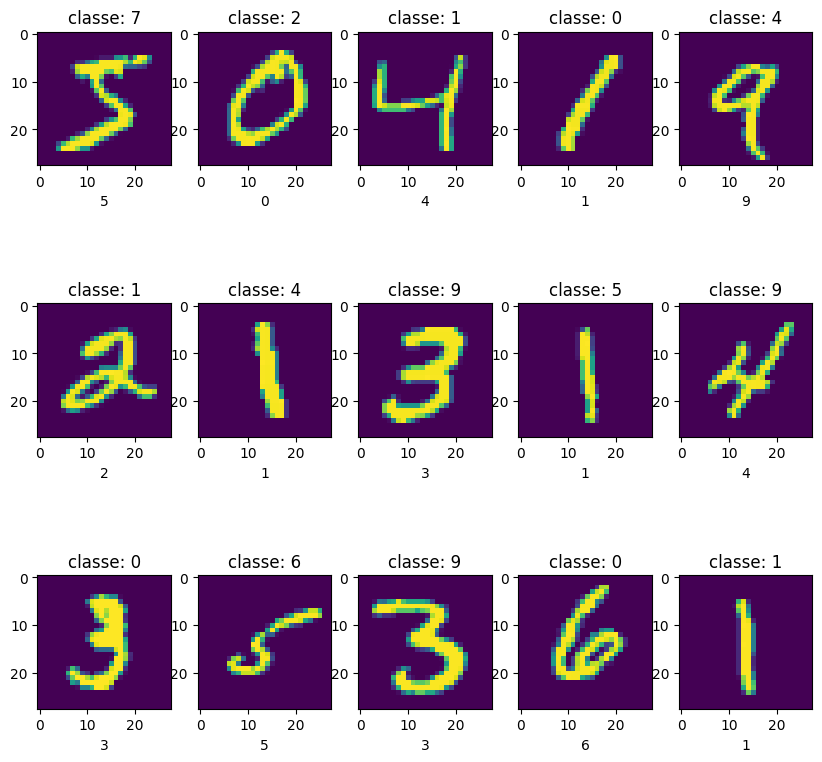

In [ ]:
plt.figure(figsize=(10, 10))
for indece in range(15):
  plt.subplot(3, 5, indece+1)
  plt.imshow(imagens_treino[indece])
  plt.title(f'classe: {tf.argmax(rotulos_teste_one_hot[indece])}')
  plt.xlabel(rotulos_treino[indece])
plt.show()

In [ ]:
modelo_mlp = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])
modelo_mlp.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# opt = tf.keras.optimizers.Adam(learning_rate=0.01)
# opt = tf.keras.optimizers.SGD(learning_rate=0.01) # fiz
# opt = tf.keras.optimizers.RMSprop(learning_rate=0.01) # fiz
# opt = tf.keras.optimizers.Adagrad(learning_rate=0.01) # fiz
# opt = tf.keras.optimizers.Adadelta(learning_rate=0.01) # fiz
opt = tf.keras.optimizers.AdamW(learning_rate=0.01)
modelo_mlp.compile(
    optimizer=opt,
    loss='mse',
    metrics=['mse']
)

In [ ]:

historico_treino = modelo_mlp.fit(
    imagens_treino,
    rotulos_treino_one_hot,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0142 - mse: 0.0142 - val_loss: 0.0097 - val_mse: 0.0097
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0112 - mse: 0.0112 - val_loss: 0.0099 - val_mse: 0.0099
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0115 - mse: 0.0115 - val_loss: 0.0082 - val_mse: 0.0082
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0110 - mse: 0.0110 - val_loss: 0.0098 - val_mse: 0.0098
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0110 - mse: 0.0110 - val_loss: 0.0099 - val_mse: 0.0099


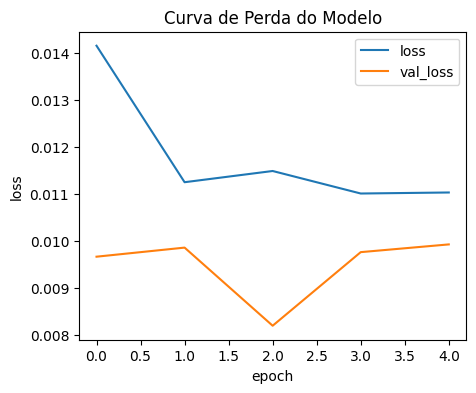

In [ ]:
plt.figure(figsize=(5, 4))
plt.plot(historico_treino.history['loss'], label='loss')
plt.plot(historico_treino.history['val_loss'], label='val_loss')
plt.title('Curva de Perda do Modelo')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend()
plt.show()

In [ ]:
modelo_mlp.save('modelo_mlp.keras')

In [ ]:
modelo_mlp_carregado = tf.keras.models.load_model('modelo_mlp.keras')

indece_amostra = 0
amostra = imagens_teste[indece_amostra]
amostra_reshaped = np.expand_dims(amostra, axis=0)

predicao = modelo_mlp_carregado.predict(amostra_reshaped)
print(f'predição: {np.argmax(predicao)} | Real: {rotulos_teste[indece_amostra]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
predição: 7 | Real: 7


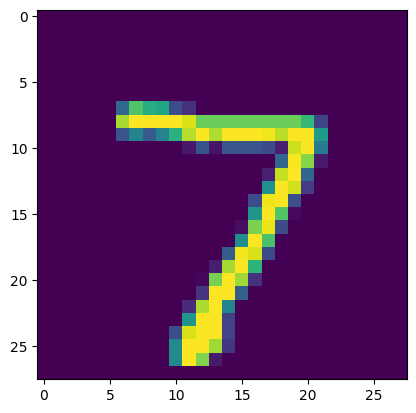

In [ ]:
plt.imshow(amostra)


# **Exemplo 2: Aula 03**

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

iris = load_iris()
caracteristicas = iris.data
especies = iris.target

display(pd.DataFrame(caracteristicas, columns=iris.feature_names).head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


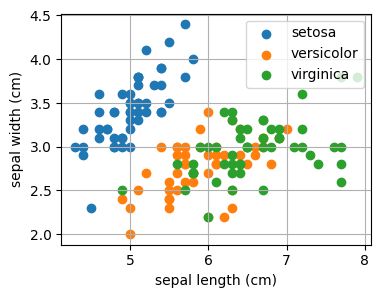

In [ ]:
plt.figure(figsize=(4, 3))
for i, nome_alvo in enumerate(iris.target_names):
  plt.scatter(caracteristicas[especies == i, 0], caracteristicas[especies == i, 1], label=nome_alvo)

plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
esconder = OneHotEncoder(sparse_output=False)
especies_escoder = esconder.fit_transform(especies.reshape(-1, 1))

print("Exemplo de Espercie codificada")
print(especies_escoder[:5])

Exemplo de Espercie codificada
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


In [ ]:
caracteristicas_treino, caracteristicas_teste, especies_treino, especies_teste = train_test_split(
    caracteristicas, especies_escoder, test_size=0.2, random_state=42
)

In [ ]:
padronizador = StandardScaler()
caracteristicas_treino = padronizador.fit_transform(caracteristicas_treino)
caracteristicas_teste = padronizador.transform(caracteristicas_teste)


In [ ]:
modelo_mlp = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4,)),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax'),
    ])

In [ ]:
modelo_mlp.compile( optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

historico = modelo_mlp.fit(caracteristicas_treino, especies_treino, epochs=60, validation_split=0.1)

Epoch 1/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.0093 - loss: 1.2341 - val_accuracy: 0.0000e+00 - val_loss: 1.2022
Epoch 2/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0093 - loss: 1.2068 - val_accuracy: 0.0000e+00 - val_loss: 1.1857
Epoch 3/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0093 - loss: 1.1804 - val_accuracy: 0.0000e+00 - val_loss: 1.1690
Epoch 4/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0185 - loss: 1.1534 - val_accuracy: 0.0000e+00 - val_loss: 1.1527
Epoch 5/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0278 - loss: 1.1291 - val_accuracy: 0.0833 - val_loss: 1.1370
Epoch 6/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0463 - loss: 1.1048 - val_accuracy: 0.1667 - val_loss: 1.1217
Epoch 7/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0833 - loss: 1.0801 - val_accuracy: 0.1667 - val_loss: 1.1068
Epoch 8/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1481 - loss: 1.0579 - val_accuracy: 0.1667 - v

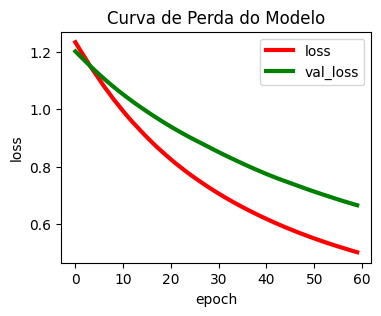

In [ ]:
plt.figure(figsize=(4, 3))
plt.plot(historico.history['loss'], label='loss', color="red", linewidth=3)
plt.plot(historico.history['val_loss'], label='val_loss', color="green", linewidth=3)
plt.title('Curva de Perda do Modelo')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend()
plt.show()

## **Exemplo 3**